# Narcolepsy Drug Adverse Reaction Profiles

Pulls the gold analysis view from DuckDB into pandas and compares the top 10 adverse reactions across the four FDA-approved narcolepsy medications represented in the data: Xyrem, Xywav, Wakix, and Sunosi.

## Finding

The four drugs have visibly distinct adverse reaction profiles:

- **Wakix** (pitolisant, Harmony Biosciences) stands out with elevated insomnia, headache, and drug ineffective reports, consistent with its different mechanism of action (histamine H3 receptor antagonist) compared to the oxybate family.
- **Xyrem and Xywav** look similar, as expected given they are both sodium oxybate formulations from the same manufacturer.
- **Sunosi** (solriamfetol) shows elevated drug ineffective and anxiety reports.

See `reaction_heatmap.png` for the visualization.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Jupyter/VS Code display settings for wider output and nicer plots
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

# Connect to the project's DuckDB file
con = duckdb.connect("../data/warehouse.duckdb", read_only=True)

print("Connected to DuckDB.")

Connected to DuckDB.


In [2]:
df = con.execute("SELECT * FROM gold_analysis_view").df()

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (26382, 14)
Columns: ['reaction_id', 'safety_report_id', 'receive_date', 'receive_year', 'source_country', 'seriousness', 'patient_age', 'patient_sex', 'drug_id', 'drug_name', 'generic_name', 'manufacturer_name', 'drug_indication', 'reaction_term']


,reaction_id,safety_report_id,receive_date,receive_year,source_country,seriousness,patient_age,patient_sex,drug_id,drug_name,generic_name,manufacturer_name,drug_indication,reaction_term
0,1,10007294,2014-03-11,2014,US,Serious,41,Female,3,XYREM,SODIUM OXYBATE,"Jazz Pharmaceuticals, Inc.",INSOMNIA,Off label use
1,2,10007294,2014-03-11,2014,US,Serious,41,Female,3,XYREM,SODIUM OXYBATE,"Jazz Pharmaceuticals, Inc.",INSOMNIA,Surgery
2,3,10007710,2014-03-11,2014,US,Serious,39,Female,3,XYREM,SODIUM OXYBATE,"Jazz Pharmaceuticals, Inc.",NARCOLEPSY,Cardiac ablation
3,4,10007710,2014-03-11,2014,US,Serious,39,Female,3,XYREM,SODIUM OXYBATE,"Jazz Pharmaceuticals, Inc.",NARCOLEPSY,Medical device implantation
4,5,10007710,2014-03-11,2014,US,Serious,39,Female,3,XYREM,SODIUM OXYBATE,"Jazz Pharmaceuticals, Inc.",NARCOLEPSY,Dermatitis contact


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26382 entries, 0 to 26381
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   reaction_id        26382 non-null  int32         
 1   safety_report_id   26382 non-null  str           
 2   receive_date       26382 non-null  datetime64[us]
 3   receive_year       26382 non-null  int32         
 4   source_country     26382 non-null  str           
 5   seriousness        26382 non-null  str           
 6   patient_age        14589 non-null  Int32         
 7   patient_sex        26382 non-null  str           
 8   drug_id            26382 non-null  int32         
 9   drug_name          26382 non-null  str           
 10  generic_name       26382 non-null  str           
 11  manufacturer_name  26382 non-null  str           
 12  drug_indication    16374 non-null  str           
 13  reaction_term      26382 non-null  str           
dtypes: Int32(1), date

In [4]:
# Row counts per drug
print("Rows per drug:")
print(df["drug_name"].value_counts())
print()

# Seriousness distribution
print("Seriousness breakdown:")
print(df["seriousness"].value_counts(normalize=True).round(3))
print()

# Date range and year distribution
print(f"Date range: {df['receive_date'].min().date()} to {df['receive_date'].max().date()}")
print()
print("Reports per year:")
print(df["receive_year"].value_counts().sort_index())

Rows per drug:
drug_name
XYREM     13430
WAKIX      5296
XYWAV      5199
SUNOSI     2457
Name: count, dtype: int64

Seriousness breakdown:
seriousness
Serious        0.764
Non-serious    0.236
Name: proportion, dtype: float64

Date range: 2013-11-25 to 2021-11-01

Reports per year:
receive_year
2013       30
2014     3577
2015      691
2016     1374
2017     1424
2018     1338
2019     2176
2020    10234
2021     5538
Name: count, dtype: int64


In [5]:
# Reactions per year, broken down by drug
yearly = df.groupby(["receive_year", "drug_name"]).size().unstack(fill_value=0)
print(yearly)

drug_name     SUNOSI  WAKIX  XYREM  XYWAV
receive_year                             
2013               0      0     30      0
2014               0      0   3577      0
2015              61     29    533     68
2016             156    196   1004     18
2017             303     58   1039     24
2018              87    138   1113      0
2019             367    234   1493     82
2020            1335   4529   4242    128
2021             148    112    399   4879


In [6]:
# Top 10 reactions overall across all four drugs combined.
# Using a shared top-10 set makes the heatmap comparable (same rows per column).
top_reactions = (
    df["reaction_term"]
    .value_counts()
    .head(10)
    .index
    .tolist()
)

print("Top 10 reactions overall:")
for r in top_reactions:
    print(f"  {r}")

Top 10 reactions overall:
  Anxiety
  Nausea
  Headache
  Drug ineffective
  Fatigue
  Condition aggravated
  Somnolence
  Weight decreased
  Dizziness
  Insomnia


In [7]:
# Count how often each top-10 reaction appears for each drug
matrix = (
    df[df["reaction_term"].isin(top_reactions)]
    .groupby(["reaction_term", "drug_name"])
    .size()
    .unstack(fill_value=0)
)

# Normalize to percentages: what share of each drug's reports mention this reaction?
# This is fairer than raw counts because the drugs have very different total volumes.
drug_totals = df["drug_name"].value_counts()
matrix_pct = matrix.div(drug_totals, axis=1) * 100

# Reorder rows so the most common overall reactions come first
matrix_pct = matrix_pct.reindex(top_reactions)

# Reorder columns by drug approval age (oldest to newest)
matrix_pct = matrix_pct[["XYREM", "XYWAV", "WAKIX", "SUNOSI"]]

matrix_pct.round(1)

drug_name,XYREM,XYWAV,WAKIX,SUNOSI
reaction_term,,,,
Anxiety,2.0,2.1,2.5,2.9
Nausea,1.9,1.9,3.3,1.8
Headache,1.3,1.2,3.5,1.8
Drug ineffective,0.9,1.0,3.9,3.4
Fatigue,1.6,0.8,2.7,1.8
Condition aggravated,1.5,1.9,0.5,1.6
Somnolence,1.3,1.1,2.0,0.9
Weight decreased,1.4,1.9,0.3,1.1
Dizziness,1.2,1.6,0.7,1.2


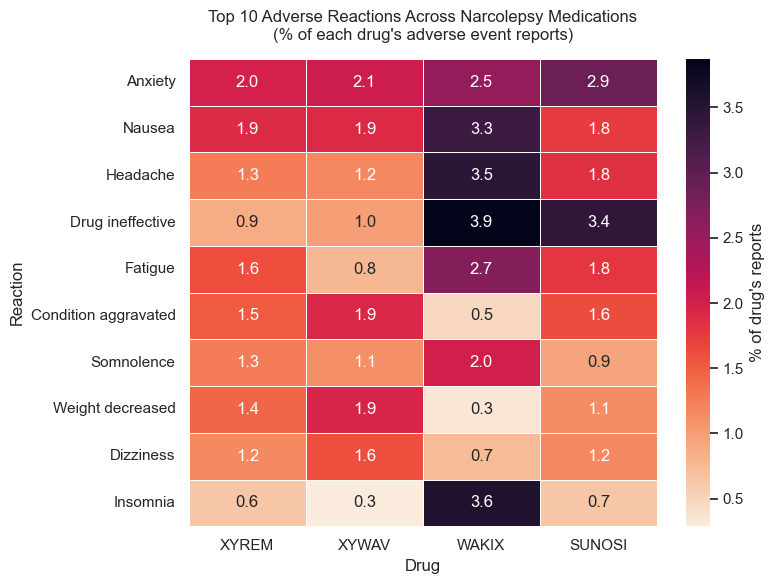

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    matrix_pct,
    annot=True,
    fmt=".1f",
    cmap="rocket_r",
    cbar_kws={"label": "% of drug's reports"},
    linewidths=0.5,
    linecolor="white",
    ax=ax,
)

ax.set_title(
    "Top 10 Adverse Reactions Across Narcolepsy Medications\n"
    "(% of each drug's adverse event reports)",
    pad=14,
)
ax.set_xlabel("Drug")
ax.set_ylabel("Reaction")

plt.tight_layout()
plt.show()

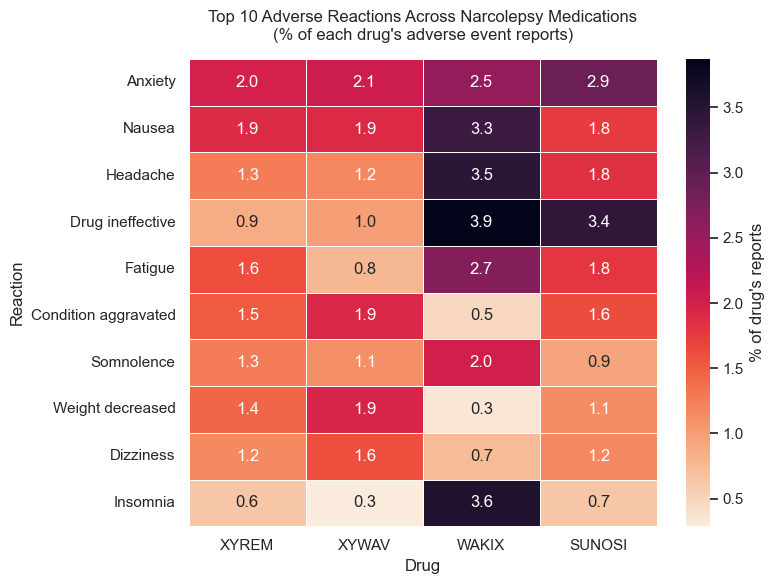

Saved reaction_heatmap.png


In [9]:
# Re-render and save to disk. plt.savefig needs to happen before plt.show()
# closed the figure, so this is a fresh render.

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    matrix_pct,
    annot=True,
    fmt=".1f",
    cmap="rocket_r",
    cbar_kws={"label": "% of drug's reports"},
    linewidths=0.5,
    linecolor="white",
    ax=ax,
)

ax.set_title(
    "Top 10 Adverse Reactions Across Narcolepsy Medications\n"
    "(% of each drug's adverse event reports)",
    pad=14,
)
ax.set_xlabel("Drug")
ax.set_ylabel("Reaction")

plt.tight_layout()

# Save to notebooks/reaction_heatmap.png, where the README can reference it
plt.savefig("reaction_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved reaction_heatmap.png")